# Sparekalkulator
I denne oppgåva ser eg på korleis ein person kan sette av eit månadleg beløp i pensjonssparing over eit gitt antal år.

Programmet spør brukaren om input om kor mykje hen vil spare per månad, forventa årleg rente og kor mange år hen vil spare (fram til peensjonsalder). I utviklinga av programmet har eg nytta eit sparebeløp på 1500kr per månad, ei årleg rente på 6% (0.06 - her tek eg sikte på at sparinga skjer i eit fond eller ein askjesparekonto med høgare avkastning enn ein sparekonto) og 35 år med sparing. Går ein ut ifrå ein pensjonsalder på 70 år, vil det sei at brukaren startar å spare i ein alder på 35 år. Alle desse parameterane kan sjølvsagt endrast av brukar ved å kjøre årogrammet på nytt.

Formelen eg brukar, formel for sluttverdi av ein oppsparingsannuitet, er litt annleis enn i oppgåvene vi har brukt tidlegare, men den er lettare å kombinere med månadlege innbetalingar over eit gitt antal år. Dersom brukaren vil sjå lista med verdien ved kvar innbetaling, er det berre å fjerne "#" før print(K), men sjølve lista gir ikkje så mykje praktisk informasjon anna enn å vere basisen for grafen som viser verdiveksten.

Terminbeløp: 
1500
Årleg rente på desimaltalsform: 
0.03
Antal innbetalingar per år: 
12
Antal år: 
30
Nominell framtidsverdi ved fast innbetaling av kr. 1500 , 12 gongar per år i  30 år, er kr. 874105.33


Text(0.5, 1.0, 'Pensjonssparing, nominell verdi')

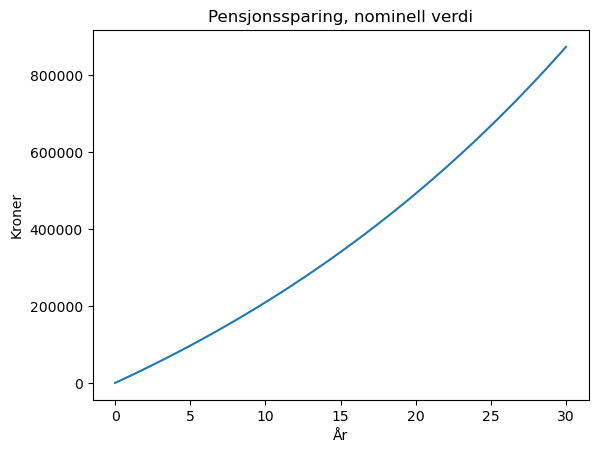

In [3]:
import numpy as np
import matplotlib.pyplot as plt


P = int(input("Terminbeløp: \n")) #Sparebeløp per månad
r_year = float(input("Årleg rente på desimaltalsform: \n")) #Årleg rente
r_month = r_year / 12 #Månadleg rente
n = int(input("Antal innbetalingar per år: \n")) #Antal terminar per år
y = int(input("Antal år: \n")) #Antal år innbetalingane skjer
t = np.linspace(0, y * n, y * n) #Antal terminar totalt i spareperioden
y_series = np.linspace(0, y, y*n) #Talfølge med spareterminar
y_series2 = np.linspace(0, y, y)
inflasjon = 0.02
termin = n * y #Antal terminar
inflasjon_month = inflasjon / 12


K = np.round(((P / r_month) * (((1 + r_month)**t) - 1)), 2)
FV = np.round(((P / r_month) * (((1 + r_month)**termin) - 1)), 2) #FV = Future Value, altså sluttverdi

#print(K)

print("Nominell framtidsverdi ved fast innbetaling av kr.", P, ",", n, "gongar per år i ", y, "år, er kr.", FV)
plt.xlabel("År")
plt.ylabel("Kroner")
plt.plot(y_series, K)
plt.title("Pensjonssparing, nominell verdi")


## Reell verdi etter inflasjon
Til no har eg berre funne den nominelle verdien av pengane som er spart opp etter y år. For å finne ut kva den faktiste kjøpekrafta dette beløpet inneberer, lagar eg ei liste med verdien etter kvar termin der terminvis rente og inflasjon er tatt med.

Når vi tek hensyn til ein inflasjon på 2% per år, er den reelle verdien i dagens kroneverdi lik kr. 629966.86


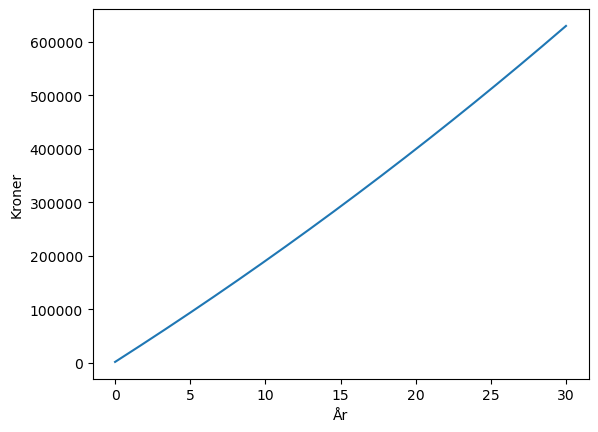

In [5]:
    
realverdi = []
for i in range(termin):
    if i < 1:
        #r_verdi = F[i]
        r_verdi = P * (1 + r_month - inflasjon_month)
    else:
        r_verdi = (realverdi[i-1] + P) * (1 + r_month - inflasjon_month)
    realverdi.append(r_verdi)
    
print("Når vi tek hensyn til ein inflasjon på 2% per år, er den reelle verdien i dagens kroneverdi lik kr.", np.round(realverdi[termin-1], 2))

plt.xlabel("År")
plt.ylabel("Kroner")
plt.plot(y_series, realverdi)

## Utbetaling av pensjon
Tek utgangspunkt i at den oppsparte pensjonen skal utbetalast over 15 år. Kva får ein utbetalt kvar månad? Gå ut ifrå ein skatt på 30% av renteinntektene. For å gjere det enklare, finn eg skatten av det totale renteinntektene i oppsparingsperioden, og fordeler den jamt ut over utbetalingane. Eg kallar den for skatt_fast. Skatt på renteinntekt i utbetalingspreioden blir trekt i effektiv rente (r_eff).

In [10]:
skatt = 0.3
r_eff = r_month * (1 - skatt) #Effektiv rente, når den delen av renta som går til skatt er tatt bort
utbetalingsår = 15
t_utb = utbetalingsår * 12 #Antal utbetalingsterminar
total_innbetaling = P * y * n
renteinntekt_oppsparing = FV - total_innbetaling #Den delen av totalt beløp før utbetaling som er av renter
skatt_fast = (renteinntekt_oppsparing * (1 - skatt)) / t_utb #Skatt av renteinntekter i spareprioden per utbetalingstermin

pensjon_termin = np.round((FV * (((r_eff * (1 + r_eff)**t_utb)) / (((1 + r_eff)**t_utb) - 1))) - skatt_fast, 2) #Utbetalt pensjon per termin

print("Etter", y, "år med pensjonsoppsparing, får brukaren utbetalt kr.", pensjon_termin, "per månad i", utbetalingsår, "år,")


Etter 30 år med pensjonsoppsparing, får brukaren utbetalt kr. 4365.99 per månad i 15 år,


### Kommentar

VI ser at den årlege inflasjonen et opp mykje av renteinntektene. I tilleg må ein betale skatt av renteinntekten, derfor er det utbetalingane mindre ein sikkert kunne håpe. Likevel er utbetalinga per månad nesten 50% høgare enn kva berre den samla innbetalinga skulle tilseie (1500 * 12 * 30 / (12 * 15) = 3000).